# Quantum simulation del dimero — evoluzione $e^{-iHt}$ via Suzuki-Trotter

Piano operativo confermato:

- **2 qubit**, nessuna ancilla (le correlazioni dinamiche sono rimandate).
- **$D\neq0$ diretto**, niente caso $D=0$ come tappa separata.
- **Osservabile:** $S_z$ totale.
- **Stato iniziale:** $|00\rangle$.
- **Metodo:** Suzuki-Trotter al prim'ordine.
- **Parametri:** da esplorare con la dinamica esatta, partendo da $J=2b$, $D=b/3$,
  cercando un regime con oscillazioni **non monocromatiche**.

$$H = b(s_{z1}+s_{z2}) + J\,\vec s_1\cdot\vec s_2 + D(s_{x1}s_{z2}-s_{z1}s_{x2}) = H_1+H_2$$

con $H_1 = b(s_{z1}+s_{z2})+J\vec s_1\cdot\vec s_2$ e $H_2 = D(s_{x1}s_{z2}-s_{z1}s_{x2})$.

**Convenzione di ordinamento.** Spin 1 $\to$ qubit 0, spin 2 $\to$ qubit 1. Le stringhe
di Pauli di Qiskit sono *little-endian*: in `Pauli('AB')` l'operatore $B$ agisce sul
qubit 0. Quindi $X_1Z_2 \equiv$ `Pauli('ZX')` e $Z_1X_2\equiv$ `Pauli('XZ')`.

## 1. Import e definizione dell'Hamiltoniana

In Pauli, con $s_i^\alpha=\sigma_i^\alpha/2$:

$$H_1 = \frac{b}{2}(Z_1+Z_2)+\frac{J}{4}(XX+YY+ZZ),\qquad H_2=\frac{D}{4}(X_1Z_2-Z_1X_2)$$

In [1]:
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, Operator, Statevector
from qiskit_aer import AerSimulator
from IPython.display import display, Image, clear_output
import io

P = lambda s: Pauli(s).to_matrix()
Z1, Z2 = P('IZ'), P('ZI')
SZ_TOT = (Z1 + Z2) / 2
PSI0 = np.array([1, 0, 0, 0], dtype=complex)      # |00> = |up up>

def H_parts(b, J, D):
    H1 = b/2*(Z1+Z2) + J/4*(P('XX')+P('YY')+P('ZZ'))
    H2 = D/4*(P('ZX') - P('XZ'))                  # X1Z2 - Z1X2
    return H1, H2

def sz(psi):
    return float(np.real(psi.conj() @ SZ_TOT @ psi))

def U_exact(b, J, D, t):
    H1, H2 = H_parts(b, J, D)
    return sla.expm(-1j*(H1+H2)*t)

def U_trotter_mat(b, J, D, t, N):
    """Prodotto di Trotter a matrice. Il circuito applica prima H1 e poi H2, quindi
    il passo in forma matriciale e' U_step = e^{-iH2 tau} e^{-iH1 tau} (vedi 4.1)."""
    H1, H2 = H_parts(b, J, D); tau = t/N
    return np.linalg.matrix_power(sla.expm(-1j*H2*tau) @ sla.expm(-1j*H1*tau), N)

ts = np.linspace(0, 30, 601)

def sz_traj(b, J, D, ts):
    return np.array([sz(U_exact(b, J, D, t) @ PSI0) for t in ts])

# Base degli stati di spin (usata nella Sezione 3)
T_p = np.array([1, 0,  0, 0], dtype=complex)              # |T+1> = |00>
T_0 = np.array([0, 1,  1, 0], dtype=complex)/np.sqrt(2)   # |T0>
T_m = np.array([0, 0,  0, 1], dtype=complex)              # |T-1> = |11>
SNG = np.array([0, 1, -1, 0], dtype=complex)/np.sqrt(2)   # |S>

# Punti di lavoro (R1 e' DERIVATO nella Sezione 3.4)
R0 = dict(b=1.0,   J=2.0, D=1/3)   # suggerimento del relatore: J=2b, D=b/3
R1 = dict(b=-0.18, J=1.0, D=1.0)   # punto adottato

def _mostra_figura(fig, out=None, testo=None):
    """Rende la figura come un singolo blob PNG e la mostra con UN SOLO display(),
    in un UNICO ingresso al context 'out'. Bypassa plt.show()/l'hook automatico
    del backend inline (che in alcuni frontend, es. VS Code, puo' duplicare il
    rendering). out=None -> mostra nella cella corrente."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image(data=buf.getvalue())
    if out is None:
        clear_output(wait=True)
        display(img)
        if testo: print(testo)
    else:
        with out:
            clear_output(wait=True)
            display(img)
            if testo: print(testo)

## 2. $S_z(t)$ è una sonda diretta del termine DM

Osservazione strutturale, da verificare prima di tutto il resto: lo stato iniziale
$|00\rangle=|\!\uparrow\uparrow\rangle$ è il tripletto $|T_{+1}\rangle$, **autostato
di $H_1$** (autostato sia del campo, $M=+1$, sia dello scambio isotropo, $S=1$).
Quindi per $D=0$ l'evoluzione produce solo una fase globale:

$$e^{-iH_1t}|00\rangle = e^{-i\varphi(t)}|00\rangle \;\Longrightarrow\; \langle S_z\rangle(t)=1 \ \ \forall t$$

La dinamica di $S_z$ **esiste solo grazie al termine DM**. Motivo fisico: sotto
scambio $1\leftrightarrow2$ il termine DM è *antisimmetrico*, quindi accoppia il
settore tripletto (simmetrico) con il singoletto (antisimmetrico) — ed è l'unico
termine di $H$ che rompe la conservazione di $S_z$.

Questo giustifica *a posteriori* la scelta di andare direttamente a
$D\neq0$: con $D=0$ l'osservabile richiesta sarebbe identicamente costante.

In [2]:
print("D=0    -> escursione di Sz:", np.ptp(sz_traj(1.0, 2.0, 0.0, ts)))
print("D=1/3  -> escursione di Sz:", np.ptp(sz_traj(1.0, 2.0, 1/3, ts)))

D=0    -> escursione di Sz: 3.008704396734174e-14
D=1/3  -> escursione di Sz: 0.006199259177924965


## 3. Scelta del punto di lavoro

Il relatore chiede oscillazioni **non monocromatiche**, partendo da $J=2b$, $D=b/3$.
Quel punto di partenza non funziona (lo si verifica in 3.2), quindi serve una
procedura per trovarne uno che funzioni. Questa sezione la costruisce **dalla
struttura dell'Hamiltoniana**, non per tentativi.

### Cosa sono i "livelli", e perché sono 4

Ogni spin-1/2 ha 2 stati, quindi due spin danno uno spazio di Hilbert di dimensione
$2^2=4$: la base computazionale è $\{|00\rangle,|01\rangle,|10\rangle,|11\rangle\}$ e
$H$ è una matrice $4\times4$. Diagonalizzandola si ottengono **4 autovalori**
$E_0\le E_1\le E_2\le E_3$ — i quattro *livelli energetici* del dimero — con i
rispettivi autostati $|k\rangle$:

$$H|k\rangle = E_k|k\rangle,\qquad k=0,1,2,3$$

L'indice $k$ è dunque **l'etichetta di un autostato**, ordinato per energia crescente
($k=0$ è il fondamentale): è la convenzione di `np.linalg.eigh`.

### Da dove vengono le frequenze

Scomponendo lo stato iniziale sugli autostati, $|\psi_0\rangle=\sum_k c_k|k\rangle$
con $c_k=\langle k|\psi_0\rangle$, ogni componente evolve con la propria fase
$e^{-iE_kt}$, e il valore di aspettazione diventa una doppia somma su **coppie** di
autostati:

$$\langle S_z\rangle(t)=\sum_{k,l} c_k^*c_l\,(S_z)_{kl}\;e^{-i(E_l-E_k)t},\qquad (S_z)_{kl}\equiv\langle k|S_z|l\rangle$$

$k$ e $l$ etichettano i **due autostati la cui interferenza genera un dato modo di
oscillazione**. Due semplificazioni:

- i termini con $k=l$ hanno esponente nullo: danno la **costante** attorno a cui il
  segnale oscilla, non un'oscillazione;
- i termini $(k,l)$ e $(l,k)$ sono uno il complesso coniugato dell'altro: descrivono
  lo **stesso** modo fisico, e sommandoli si ottiene una quantità reale.

Per questo si somma solo su $k<l$, cioè su ogni **coppia non ordinata** contata una
volta sola:

$$\langle S_z\rangle(t)=\underbrace{\sum_k |c_k|^2 (S_z)_{kk}}_{\text{costante}} + \sum_{k<l} \underbrace{2\,\mathrm{Re}\!\left[c_k^*c_l (S_z)_{kl}\, e^{-i\Delta_{kl}t}\right]}_{\text{modo di frequenza }\Delta_{kl}},\qquad \Delta_{kl}\equiv E_l-E_k>0$$

Con 4 livelli le coppie con $k<l$ sono $\binom{4}{2}=6$: **al massimo 6 frequenze**.
Ogni modo ha ampiezza $a_{kl}=2|c_k^*c_l (S_z)_{kl}|$, prodotto di due fattori:
quanto lo stato iniziale popola i due livelli ($|c_k^*c_l|$) e quanto $S_z$ li
connette ($|(S_z)_{kl}|$). Se uno dei due si annulla, quel modo è assente.

**"Non monocromatico"** significa allora: almeno due $\Delta_{kl}$ *distinte* con
ampiezze $a_{kl}$ *confrontabili*. Le sezioni 3.1–3.4 traducono questo requisito in
due condizioni sui parametri, e da lì ricavano il punto di lavoro.

*(Sull'ordine degli indici: la convenzione standard è $\omega_{kl}=(E_k-E_l)/\hbar$,
quindi $\Delta_{kl}=\omega_{lk}$; qui si usa $\Delta$ con indici ordinati per avere
frequenze positive senza ambiguità di segno.)*

In [3]:
def modi(b, J, D, tol=1e-6):
    """Modi spettrali di <Sz>(t): lista di (frequenza di Bohr, ampiezza), ordinata."""
    E, V = np.linalg.eigh(sum(H_parts(b, J, D)))
    c = V.conj().T @ PSI0
    S = V.conj().T @ SZ_TOT @ V
    m = {}
    for k in range(4):
        for l in range(k+1, 4):
            a = abs(2*np.real(np.conj(c[k])*c[l]*S[k, l]))
            if a > tol:
                m[round(E[l]-E[k], 3)] = m.get(round(E[l]-E[k], 3), 0) + a
    return sorted(m.items(), key=lambda r: -r[1])

### 3.1 La struttura degli accoppiamenti: il dimero è un sistema a V

Conviene lavorare nella base di spin $\{|T_{+1}\rangle,|T_0\rangle,|T_{-1}\rangle,|S\rangle\}$
anziché in quella computazionale, perché lì $H_1$ è **diagonale**:

$$E(T_{\pm1})=\pm b+\tfrac J4,\qquad E(T_0)=\tfrac J4,\qquad E(S)=-\tfrac{3J}{4}$$

mentre il termine DM $H_2$ ha una struttura di accoppiamento molto selettiva.

In [4]:
H1, H2 = H_parts(-0.18, 1.0, 1.0)
nomi, vecs = ['T+1', 'T0', 'T-1', 'S'], [T_p, T_0, T_m, SNG]

print("Energie imperturbate (H1 e' diagonale in questa base):")
for n, v in zip(nomi, vecs):
    print(f"  E({n:3s}) = {np.real(v.conj() @ H1 @ v):+.4f}")

print("\nAccoppiamenti dovuti al termine DM:")
for i, (n1, v1) in enumerate(zip(nomi, vecs)):
    for n2, v2 in list(zip(nomi, vecs))[i+1:]:
        x = np.real(v1.conj() @ H2 @ v2)
        flag = "   <== accoppiati" if abs(x) > 1e-12 else ""
        print(f"  <{n1:3s}|H2|{n2:3s}> = {x:+.4f}{flag}")

print("\nValore dell'accoppiamento non nullo, confrontato con D/(2*sqrt2):")
for Dv in [0.3, 1.0, 1.7]:
    v = np.real(T_p.conj() @ H_parts(0, 1, Dv)[1] @ SNG)
    print(f"  D={Dv}:  numerico={v:.5f}   D/(2*sqrt2)={Dv/(2*np.sqrt(2)):.5f}")

Energie imperturbate (H1 e' diagonale in questa base):
  E(T+1) = +0.0700
  E(T0 ) = +0.2500
  E(T-1) = +0.4300
  E(S  ) = -0.7500

Accoppiamenti dovuti al termine DM:
  <T+1|H2|T0 > = +0.0000
  <T+1|H2|T-1> = +0.0000
  <T+1|H2|S  > = +0.3536   <== accoppiati
  <T0 |H2|T-1> = +0.0000
  <T0 |H2|S  > = +0.0000
  <T-1|H2|S  > = +0.3536   <== accoppiati

Valore dell'accoppiamento non nullo, confrontato con D/(2*sqrt2):
  D=0.3:  numerico=0.10607   D/(2*sqrt2)=0.10607
  D=1.0:  numerico=0.35355   D/(2*sqrt2)=0.35355
  D=1.7:  numerico=0.60104   D/(2*sqrt2)=0.60104


**Il risultato è una struttura a V.** Il DM accoppia il singoletto a *entrambi* i
tripletti $|T_{\pm1}\rangle$ con la stessa forza $V=D/(2\sqrt2)$, non accoppia
$|T_{+1}\rangle$ a $|T_{-1}\rangle$, e **annichilla $|T_0\rangle$**:

$$|T_{+1}\rangle \;\xleftrightarrow{\;V\;}\; |S\rangle \;\xleftrightarrow{\;V\;}\; |T_{-1}\rangle,\qquad V=\frac{D}{2\sqrt2}$$

Quindi $|T_0\rangle$ è **fuori gioco** (verifica completa in 3.6) e i livelli
dinamicamente attivi sono **3**, non 4. Lo stato iniziale è
$|00\rangle=|T_{+1}\rangle$, cioè un braccio della V.

Le due quantità che governano tutto sono i **detuning** dei due bracci rispetto al
singoletto:

$$\Delta_+ = E(T_{+1})-E(S) = b+J,\qquad \Delta_- = E(T_{-1})-E(S) = -b+J$$

Da qui escono le due condizioni sui parametri.

> **Riscontro con la teoria del progetto.** Questa struttura non è nuova: in
> `simmetrie_dmi_spin.pdf` (§11.2.2 e §13.3, "Caso B") si mostra che con $\vec D$ nel
> piano trasversale la DMI accoppia il singoletto ai tripletti $M=\pm1$ lasciando
> inalterato $M=0$. Il termine $D(s_{x1}s_{z2}-s_{z1}s_{x2})=-D\,(\vec s_1\times\vec s_2)_y$
> corrisponde infatti a $\vec D\parallel\hat y$, cioè $D_z=0$. La struttura a V qui
> ricavata numericamente è la stessa. **Attenzione però al valore
> dell'accoppiamento:** vedi la nota in Sezione 8.1.

### 3.2 Prima condizione: il segnale deve essere abbastanza grande

Finché $V\ll\Delta_+$, il braccio $|T_{+1}\rangle\leftrightarrow|S\rangle$ è un
problema a due livelli con accoppiamento $V$ e detuning $\Delta_+$. La popolazione
massima trasferita fuori dallo stato iniziale è data dalla formula di Rabi
$4V^2/(4V^2+\Delta_+^2)$, che per $V\ll\Delta_+$ si riduce a $4V^2/\Delta_+^2$.
Sostituendo $V=D/(2\sqrt2)$:

$$\boxed{\ \text{escursione di } \langle S_z\rangle \;\simeq\; \frac{4V^2}{\Delta_+^2} \;=\; \frac{D^2}{2\,(b+J)^2}\ }$$

È una previsione quantitativa, non qualitativa: la cella seguente la confronta con la
dinamica esatta.

In [5]:
def escursione(b, J, D):
    return np.ptp(sz_traj(b, J, D, ts))

print(f"{'b/J':>7}{'D/J':>7}{'formula':>10}{'esatto':>10}   nota")
for b, J, D, nota in [(1.0, 2.0, 1/3, 'R0 = suggerimento relatore'),
                      (0.5, 1.0, 0.3, ''),
                      (-0.5, 1.0, 0.3, ''),
                      (-0.18, 1.0, 0.2, ''),
                      (-0.18, 1.0, 0.5, ''),
                      (-0.18, 1.0, 1.0, 'R1: fuori dal regime perturbativo')]:
    print(f"{b/J:7.2f}{D/J:7.2f}{D**2/(2*(b+J)**2):10.4f}{escursione(b,J,D):10.4f}   {nota}")

    b/J    D/J   formula    esatto   nota
   0.50   0.17    0.0062    0.0062   R0 = suggerimento relatore
   0.50   0.30    0.0200    0.0203   
  -0.50   0.30    0.1800    0.1501   
  -0.18   0.20    0.0297    0.0302   
  -0.18   0.50    0.1859    0.1984   
  -0.18   1.00    0.7436    0.8433   R1: fuori dal regime perturbativo


**Diagnosi di R0.** Con $b/J=0.5$, $D/J=1/6$ la formula dà
$D^2/(2(b+J)^2)=0.0062$, e la dinamica esatta dà $0.0062$: accordo perfetto. Il punto
suggerito dal relatore sta in pieno regime perturbativo, dove il segnale è
$\sim6\times10^{-3}$ — sotto il rumore statistico di $8192$ shot, che è
$\sim1/\sqrt{8192}\simeq0.011$.

**Prima condizione:** serve $D\gtrsim(b+J)$, cioè $D$ dell'ordine di $J$ — a meno di
avvicinarsi alla risonanza $b\to-J$, dove $\Delta_+\to0$. La sezione seguente mostra
perché quella strada è preclusa.

### 3.3 Seconda condizione: servono due frequenze confrontabili

Le frequenze del segnale discendono dai due detuning $\Delta_\pm=J\pm b$: il campo
$b$ è quindi il parametro che controlla **quante** frequenze compaiono, e ci sono due
modi opposti di sbagliarlo.

- **$b\to-J$ (risonanza).** $\Delta_+\to0$: il braccio $|T_{+1}\rangle$–$|S\rangle$
  entra in risonanza e domina, mentre $|T_{-1}\rangle$ resta detunato di
  $\Delta_-=2J$. Il sistema si riduce a **due livelli** → oscillazione di Rabi di
  ampiezza piena ma **monocromatica**.
- **$b\to0$ (bracci simmetrici).** $\Delta_+=\Delta_-=J$: la V è simmetrica e lo stato
  iniziale si accoppia essenzialmente a una sola combinazione dei due bracci → di
  nuovo un modo dominante.

L'ottimo sta quindi a $|b|$ **piccolo ma non nullo**. Lo scan seguente lo localizza, a
$D/J=1$ fissato dalla prima condizione.

In [6]:
def rapporto(b, J, D):
    # rapporto a2/a1 fra le ampiezze dei due modi dominanti
    m = modi(b, J, D)
    return m[1][1]/m[0][1] if len(m) > 1 else 0.0

J, D = 1.0, 1.0
print("Scan in b/J a D/J=1 fissato:")
print(f"{'b/J':>7}{'Delta+':>9}{'Delta-':>9}{'escurs.':>10}{'a2/a1':>8}")
for bJ in [0.00, -0.05, -0.10, -0.15, -0.18, -0.20, -0.25, -0.30, -0.50, -0.80, -1.00]:
    print(f"{bJ:7.2f}{bJ+J:9.2f}{-bJ+J:9.2f}{escursione(bJ*J,J,D):10.4f}{rapporto(bJ*J,J,D):8.3f}")

griglia = np.arange(-0.35, -0.039, 0.005)
rr = [rapporto(x*J, J, D) for x in griglia]
print(f"\nMassimo di a2/a1 a b/J = {griglia[int(np.argmax(rr))]:+.3f}   (a2/a1 = {max(rr):.3f})")

Scan in b/J a D/J=1 fissato:
    b/J   Delta+   Delta-   escurs.   a2/a1
   0.00     1.00     1.00    1.9282   0.172
  -0.05     0.95     1.05    1.7133   0.256
  -0.10     0.90     1.10    1.2097   0.434
  -0.15     0.85     1.15    0.9492   0.738
  -0.18     0.82     1.18    0.8433   0.995
  -0.20     0.80     1.20    0.7730   0.831
  -0.25     0.75     1.25    0.6570   0.535
  -0.30     0.70     1.30    0.6548   0.360
  -0.50     0.50     1.50    0.6938   0.100
  -0.80     0.20     1.80    0.9150   0.026
  -1.00     0.00     2.00    1.0260   0.014

Massimo di a2/a1 a b/J = -0.180   (a2/a1 = 0.995)


Lo scan conferma entrambi i limiti previsti: a $b/J=-1$ (risonanza) si ha
$a_2/a_1\simeq0.01$ nonostante l'escursione sia piena, e a $b/J=0$ si ha
$a_2/a_1\simeq0.17$. In mezzo c'è un massimo netto attorno a $b/J\simeq-0.18$, dove i
due modi dominanti hanno ampiezze praticamente uguali.

### 3.4 Il punto di lavoro R1

Fissato $b/J=-0.18$ dalla seconda condizione, si conferma $D/J$ con la prima e si
verifica l'ampiezza del *plateau*, per non scegliere un punto su una punta instabile.

In [7]:
print("Scan in D/J a b/J=-0.18 fissato:")
print(f"{'D/J':>6}{'escurs.':>10}{'a2/a1':>8}")
for Dv in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]:
    print(f"{Dv:6.1f}{escursione(-0.18, 1.0, Dv):10.4f}{rapporto(-0.18, 1.0, Dv):8.3f}")

print("\nRobustezza: plateau attorno al punto scelto (D/J=1)")
print(f"{'b/J':>7}{'escurs.':>10}{'a2/a1':>8}{'a3/a1':>8}")
for bJ in [-0.24, -0.22, -0.20, -0.18, -0.16, -0.14, -0.12]:
    m = modi(bJ, 1.0, 1.0)
    print(f"{bJ:7.2f}{escursione(bJ,1.0,1.0):10.4f}{m[1][1]/m[0][1]:8.3f}{m[2][1]/m[0][1]:8.3f}")

Scan in D/J a b/J=-0.18 fissato:
   D/J   escurs.   a2/a1
   0.2    0.0302   0.046
   0.4    0.1239   0.187
   0.6    0.2949   0.421
   0.8    0.5467   0.715
   1.0    0.8433   0.995
   1.2    1.1269   0.810
   1.5    1.4360   0.696
   2.0    1.7558   0.659

Robustezza: plateau attorno al punto scelto (D/J=1)
    b/J   escurs.   a2/a1   a3/a1
  -0.24    0.6995   0.583   0.078
  -0.22    0.7387   0.693   0.085
  -0.20    0.7730   0.831   0.091
  -0.18    0.8433   0.995   0.098
  -0.16    0.9142   0.817   0.086
  -0.14    0.9836   0.666   0.075
  -0.12    1.0946   0.539   0.063


**Punto adottato: R1 $=(b/J=-0.18,\;D/J=1.0)$**, con escursione $0.84$ e
$a_2/a_1=0.995$ — due frequenze dominanti di ampiezza praticamente identica, la
condizione ideale di battimento.

Non è una punta instabile: tutta la fascia $b/J\in[-0.22,-0.14]$ dà $a_2/a_1>0.66$ ed
escursione $>0.73$. La posizione esatta del massimo non ha significato fisico
particolare — conta la **regione**.

Il segno negativo di $b/J$ non è artificioso: il campo è **antiparallelo** alla
polarizzazione iniziale $|\!\uparrow\uparrow\rangle$, un quench standard. Non si può
eliminare per simmetria — sotto flip globale $\Pi=X\otimes X$ vale
$\Pi H(b,J,D)\Pi=H(-b,J,-D)$, ma $\Pi|00\rangle=|11\rangle$, e lo stato iniziale è
fissato dal relatore.

### 3.5 Verifica esplicita di livelli, coefficienti e coppie in R1

Con il punto di lavoro fissato, si tabulano i 4 livelli, i pesi $|c_k|^2$ dello stato
iniziale su ciascuno, e tutte le 6 coppie $(k,l)$ con i due fattori che ne compongono
l'ampiezza. Serve a confermare numericamente la struttura derivata in 3.1.

In [8]:
# Tabella esplicita dei 4 livelli e delle 6 coppie, nel regime R1
b, J, D = R1['b'], R1['J'], R1['D']
E, V = np.linalg.eigh(sum(H_parts(b, J, D)))
c = V.conj().T @ PSI0                 # c_k = <k|psi0>
Smat = V.conj().T @ SZ_TOT @ V        # (Sz)_kl

print("I 4 livelli:")
print(" k    E_k      |c_k|^2   (Sz)_kk")
for k in range(4):
    print(f" {k}   {E[k]:+.4f}    {abs(c[k])**2:.4f}   {np.real(Smat[k,k]):+.4f}")
print(f"\n costante = sum_k |c_k|^2 (Sz)_kk = "
      f"{sum(abs(c[k])**2*np.real(Smat[k,k]) for k in range(4)):.4f}")

print("\nLe 6 coppie (k,l) con k<l:")
print(" (k,l)  Delta_kl   |c_k c_l|   |(Sz)_kl|    a_kl")
for k in range(4):
    for l in range(k+1, 4):
        a = abs(2*np.real(np.conj(c[k])*c[l]*Smat[k, l]))
        print(f" ({k},{l})   {E[l]-E[k]:.4f}     {abs(c[k]*c[l]):.4f}      "
              f"{abs(Smat[k,l]):.4f}     {a:.4f}")

I 4 livelli:
 k    E_k      |c_k|^2   (Sz)_kk
 0   -0.9611    0.0995   +0.0448
 1   +0.1609    0.8474   +0.7507
 2   +0.2500    0.0000   +0.0000
 3   +0.5502    0.0532   -0.7955

 costante = sum_k |c_k|^2 (Sz)_kk = 0.5983

Le 6 coppie (k,l) con k<l:
 (k,l)  Delta_kl   |c_k c_l|   |(Sz)_kl|    a_kl
 (0,1)   1.1220     0.2903      0.3630     0.2107
 (0,2)   1.2111     0.0000      0.0000     0.0000
 (0,3)   1.5113     0.0727      0.1426     0.0207
 (1,2)   0.0891     0.0000      0.0000     0.0000
 (1,3)   0.3893     0.2123      0.4987     0.2117
 (2,3)   0.3002     0.0000      0.0000     0.0000


### 3.6 Verifica sui livelli: il problema è effettivamente a 3 livelli

Nel regime R1 i quattro livelli sono $E=(-0.961,\,+0.161,\,+0.250,\,+0.550)$, e lo
stato iniziale $|00\rangle$ si distribuisce su di essi con pesi
$|c_k|^2=(0.100,\,0.847,\,\mathbf{0.000},\,0.053)$.

Delle 6 coppie possibili, **solo 3 danno un modo non nullo**:

| $(k,l)$ | $\Delta_{kl}$ | $\lvert c_kc_l\rvert$ | $\lvert (S_z)_{kl}\rvert$ | $a_{kl}$ |
|---|---|---|---|---|
| $(1,3)$ | $0.3893$ | $0.212$ | $0.499$ | $\mathbf{0.2117}$ |
| $(0,1)$ | $1.1220$ | $0.290$ | $0.363$ | $\mathbf{0.2107}$ |
| $(0,3)$ | $1.5113$ | $0.073$ | $0.143$ | $0.0207$ |
| $(0,2)$, $(1,2)$, $(2,3)$ | — | $\mathbf 0$ | $\mathbf 0$ | $\mathbf 0$ |

I due modi dominanti hanno ampiezze $0.2117$ e $0.2107$: è il bilanciamento cercato
in 3.3, ottenuto per costruzione e non per caso.

Tutte e tre le coppie che coinvolgono il livello $k=2$ si annullano, e si annullano
**entrambi** i fattori — come previsto in 3.1, perché l'autostato $k=2$ è

$$|T_0\rangle=\frac{|01\rangle+|10\rangle}{\sqrt2}$$

annichilato dal termine DM e autostato di $H_1$ con $E=J/4$ (si riconosce infatti
$E_2=0.250=J/4$ nella tabella). È triplamente disaccoppiato:

- $\langle T_0|00\rangle=0$ → non viene popolato dallo stato iniziale ($c_2=0$);
- $S_z|T_0\rangle=0$ → non contribuisce ad alcun elemento di matrice di $S_z$;
- è autostato esatto → non viene mescolato dall'evoluzione.

Una conseguenza da tenere presente: delle 3 frequenze superstiti solo **2 sono
indipendenti**, perché vale identicamente $\Delta_{03}=\Delta_{01}+\Delta_{13}$ (i gap
non sono liberi: sono differenze delle stesse 4 energie). Verifica:
$1.1220+0.3893=1.5113$.

Il regime "non monocromatico" migliore ottenibile è dunque a **due frequenze
indipendenti**, non a quattro.

In [9]:
b, J, D = R1['b'], R1['J'], R1['D']
H1, H2 = H_parts(b, J, D)

print("Identificazione: l'autostato k=2 e' |T0>?")
print(f"  |<T0|k=2>|^2 = {abs(T_0 @ V[:, 2])**2:.6f}")

print("\nLe tre proprieta' di disaccoppiamento:")
print("  ||H2|T0>||            :", np.linalg.norm(H2 @ T_0), "  (il DM annichila |T0>)")
print("  ||H|T0> - (J/4)|T0>|| :", np.linalg.norm((H1+H2) @ T_0 - (J/4)*T_0), "  (autostato esatto)")
print("  <T0|00>               :", np.round(T_0 @ PSI0, 12), "  (non popolato)")
print("  ||Sz|T0>||            :", np.linalg.norm(SZ_TOT @ T_0), "  (invisibile a Sz)")

print("\nE_2 = J/4 indipendente da b e D?")
for (bb, JJ, DD) in [(-0.18, 1.0, 1.0), (0.7, 1.0, 0.3), (-1.3, 2.0, 0.9)]:
    Ee, Vv = np.linalg.eigh(sum(H_parts(bb, JJ, DD)))
    k = int(np.argmin(abs(Vv.conj().T @ PSI0)))
    print(f"  b={bb:+.2f} J={JJ} D={DD}:  E_k={Ee[k]:+.4f}   J/4={JJ/4:.4f}")

print("\nSolo 2 frequenze indipendenti (Delta_03 = Delta_01 + Delta_13), regime R1:")
print(f"  Delta_01 + Delta_13 = {E[1]-E[0]:.4f} + {E[3]-E[1]:.4f} = {E[3]-E[0]:.4f}")
print(f"  Delta_03            = {E[3]-E[0]:.4f}")

Identificazione: l'autostato k=2 e' |T0>?
  |<T0|k=2>|^2 = 1.000000

Le tre proprieta' di disaccoppiamento:
  ||H2|T0>||            : 0.0   (il DM annichila |T0>)
  ||H|T0> - (J/4)|T0>|| : 0.0   (autostato esatto)
  <T0|00>               : 0j   (non popolato)
  ||Sz|T0>||            : 0.0   (invisibile a Sz)

E_2 = J/4 indipendente da b e D?
  b=-0.18 J=1.0 D=1.0:  E_k=+0.2500   J/4=0.2500
  b=+0.70 J=1.0 D=0.3:  E_k=+0.2500   J/4=0.2500
  b=-1.30 J=2.0 D=0.9:  E_k=+0.5000   J/4=0.5000

Solo 2 frequenze indipendenti (Delta_03 = Delta_01 + Delta_13), regime R1:
  Delta_01 + Delta_13 = 1.1220 + 0.3893 = 1.5113
  Delta_03            = 1.5113


### 3.7 Confronto diretto R0 / R1

In [10]:
for nome, q in [('R0', R0), ('R1', R1)]:
    E = np.linalg.eigvalsh(sum(H_parts(q['b'], q['J'], q['D'])))
    print(f"{nome}: b/J={q['b']/q['J']:+.3f}  D/J={q['D']/q['J']:.3f}  "
          f"escursione={np.ptp(sz_traj(q['b'], q['J'], q['D'], ts)):.4f}  E={np.round(E,3)}")
    for w, a in modi(q['b'], q['J'], q['D']):
        print(f"      Delta={w:7.4f}   ampiezza={a:.4f}")

R0: b/J=+0.500  D/J=0.167  escursione=0.0062  E=[-1.518 -0.486  0.5    1.505]
      Delta= 3.0230   ampiezza=0.0030
      Delta= 1.9910   ampiezza=0.0001
      Delta= 1.0320   ampiezza=0.0001
R1: b/J=-0.180  D/J=1.000  escursione=0.8433  E=[-0.961  0.161  0.25   0.55 ]
      Delta= 0.3890   ampiezza=0.2117
      Delta= 1.1220   ampiezza=0.2107
      Delta= 1.5110   ampiezza=0.0207


### 3.8 Perché la scelta del regime non è cosmetica

L'errore di Trotter dipende da $\|[H_1,H_2]\|$ e da $\tau$, **non** dall'ampiezza del
segnale. In un regime a segnale piccolo l'errore quindi *sommerge* la fisica che si
vuole riprodurre, e la validazione perde significato. La cella seguente lo quantifica
rapportando l'errore all'escursione del segnale.

In [11]:
print("Regime | escursione | ||[H1,H2]|| | N  | err. assoluto | err./escursione")
for nome, q in [('R0', R0), ('R1', R1)]:
    y = sz_traj(q['b'], q['J'], q['D'], ts)
    H1, H2 = H_parts(q['b'], q['J'], q['D'])
    nc = np.linalg.norm(H1@H2 - H2@H1)
    for N in [5, 20]:
        yT = np.array([sz(U_trotter_mat(q['b'], q['J'], q['D'], t, N) @ PSI0) for t in ts])
        e = np.max(np.abs(yT - y))
        print(f"  {nome}   |   {np.ptp(y):.4f}   |   {nc:.4f}    |{N:3d} |    {e:.5f}    |  {e/np.ptp(y):8.2f}")

Regime | escursione | ||[H1,H2]|| | N  | err. assoluto | err./escursione
  R0   |   0.0062   |   0.5270    |  5 |    0.93872    |    151.42
  R0   |   0.0062   |   0.5270    | 20 |    0.03304    |      5.33
  R1   |   0.8433   |   0.7185    |  5 |    1.44205    |      1.71
  R1   |   0.8433   |   0.7185    | 20 |    0.24978    |      0.30


**Risultato decisivo.** $\|[H_1,H_2]\|$ è simile nei due regimi ($0.53$ contro
$0.72$), quindi l'errore di Trotter in *assoluto* è confrontabile. È il **segnale** a
cambiare di due ordini di grandezza. Rapportando:

- **R0**: l'errore vale $151$ volte l'escursione a $N=5$ e $5.3$ volte a $N=20$. La
  curva "Trotter" non sarebbe un'approssimazione della dinamica, ma rumore
  algoritmico su una scala del tutto diversa da quella fisica.
- **R1**: $1.71$ volte a $N=5$ e $0.30$ volte a $N=20$ — stesso ordine del segnale,
  cioè errore **visibile e misurabile** ma non dominante, con convergenza osservabile
  al crescere di $N$ (Sezione 5).

Il regime va quindi scelto *prima* di validare Trotter, e va scelto sulla base delle
due condizioni di 3.2–3.3.

## 4. Decomposizione in gate

Blocchi derivati in `quantum_simulation_dimero_teoria.md`, con $\tau$ la durata del
singolo passo.

**Blocco $H_1$** (campo e scambio commutano perché $[S^2,S_z]=0$ $\Rightarrow$ esatto):

$$e^{-iH_1\tau}=R_z^{(1)}(b\tau)\,R_z^{(2)}(b\tau)\,R_{XX}\!\left(\tfrac{J\tau}{2}\right)R_{YY}\!\left(\tfrac{J\tau}{2}\right)R_{ZZ}\!\left(\tfrac{J\tau}{2}\right)$$

**Blocco $H_2$** ($[X_1Z_2,Z_1X_2]=0$ e $HZH=X$ $\Rightarrow$ esatto):

$$e^{-iH_2\tau}=\Big[(I\otimes H)R_{ZZ}\!\left(-\tfrac{D\tau}{2}\right)(I\otimes H)\Big]\Big[(H\otimes I)R_{ZZ}\!\left(\tfrac{D\tau}{2}\right)(H\otimes I)\Big]$$

Entrambi i blocchi sono **esatti**: l'unica approssimazione dello schema è la
separazione $e^{-i(H_1+H_2)\tau}\approx e^{-iH_1\tau}e^{-iH_2\tau}$.

**Scelta implementativa.** Il blocco $R_{ZZ}(\theta)$ è scritto qui esplicitamente
come $\text{CNOT}\cdot R_z(\theta)_{\rm target}\cdot\text{CNOT}$ anziché come gate
nativo `qc.rzz(...)`: le due forme sono identiche (verificato simbolicamente,
$\text{CNOT}(I\otimes Z)\text{CNOT}=Z\otimes Z$, quindi la coniugazione si trasporta
esattamente sull'esponenziale), ed è la stessa decomposizione contenuta nella
`.definition` interna di `RZZGate` in Qiskit. La scelta rende il conteggio di gate
a due qubit riportato più avanti realistico rispetto a un backend a
superconduttori, dove `CNOT` è nativo e `RZZ` no.

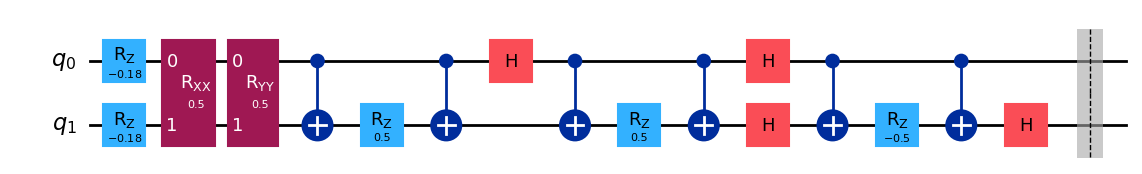

In [12]:
def step_H1(qc, b, J, tau, rappresentazione='cx'):
    qc.rz(b*tau, 0); qc.rz(b*tau, 1)
    qc.rxx(J*tau/2, 0, 1); qc.ryy(J*tau/2, 0, 1)
    if rappresentazione == 'cx':
        qc.cx(0, 1); qc.rz(J*tau/2, 1); qc.cx(0, 1)      # RZZ(J*tau/2) = CNOT-Rz-CNOT
    else:
        qc.rzz(J*tau/2, 0, 1)                             # RZZ(J*tau/2), gate nativo

def step_H2(qc, D, tau, rappresentazione='cx'):
    qc.h(0)                                       # coniuga verso X1Z2
    if rappresentazione == 'cx':
        qc.cx(0, 1); qc.rz( D*tau/2, 1); qc.cx(0, 1)     # RZZ( D*tau/2) = CNOT-Rz-CNOT
    else:
        qc.rzz(D*tau/2, 0, 1)
    qc.h(0)
    qc.h(1)                                       # coniuga verso Z1X2
    if rappresentazione == 'cx':
        qc.cx(0, 1); qc.rz(-D*tau/2, 1); qc.cx(0, 1)     # RZZ(-D*tau/2) = CNOT-Rz-CNOT
    else:
        qc.rzz(-D*tau/2, 0, 1)
    qc.h(1)

def trotter_circuit(b, J, D, t, N, measure=False, rappresentazione='cx'):
    # rappresentazione: 'cx' (esplicita, CNOT-Rz-CNOT) oppure 'nativo' (gate RZZGate di Qiskit).
    # Le due danno risultati fisici identici (stessa unita' a scarto zero); cambiano
    # solo conteggio di gate, profondita' e tempo di simulazione classica -- vedi
    # costo_gate_trotter.md per il confronto completo.
    qc = QuantumCircuit(2, 2) if measure else QuantumCircuit(2)
    tau = t/N
    for _ in range(N):
        step_H1(qc, b, J, tau, rappresentazione); step_H2(qc, D, tau, rappresentazione); qc.barrier()
    if measure:
        qc.measure([0, 1], [0, 1])
    return qc

trotter_circuit(R1['b'], R1['J'], R1['D'], 1.0, 1).draw('mpl')

### 4.1 Self-test: i blocchi devono riprodurre $e^{-iH_i\tau}$ a precisione macchina

Se un blocco non torna a $\sim10^{-16}$ c'è un errore di convenzione (fattori $1/2$,
segni, ordinamento dei qubit), non un errore di Trotter. Da verificare **prima** di
guardare qualunque risultato fisico.

Attenzione all'ordine dei fattori: il circuito applica prima $H_1$ e poi $H_2$, quindi
in forma matriciale il passo è $U_{\text{step}}=e^{-iH_2\tau}e^{-iH_1\tau}$.

In [13]:
b, J, D, tau = R1['b'], R1['J'], R1['D'], 0.37
H1, H2 = H_parts(b, J, D)

qc = QuantumCircuit(2); step_H1(qc, b, J, tau)
print("errore blocco H1 :", np.max(np.abs(Operator(qc).data - sla.expm(-1j*H1*tau))))
qc = QuantumCircuit(2); step_H2(qc, D, tau)
print("errore blocco H2 :", np.max(np.abs(Operator(qc).data - sla.expm(-1j*H2*tau))))
print("circuito vs matrice (N=5):",
      np.max(np.abs(Operator(trotter_circuit(b, J, D, 2.0, 5)).data - U_trotter_mat(b, J, D, 2.0, 5))))
print("norma di [H1,H2]:", np.linalg.norm(H1@H2 - H2@H1))

# Trotter eredita il disaccoppiamento di |T0>: entrambi i blocchi lo rispettano
pe = max(abs(T_0 @ (U_exact(b, J, D, t) @ PSI0))**2 for t in ts)
pt = max(abs(T_0 @ (U_trotter_mat(b, J, D, t, 20) @ PSI0))**2 for t in ts)
print(f"\npopolazione spuria di |T0>:  esatta={pe:.2e}   Trotter(N=20)={pt:.2e}")

errore blocco H1 : 2.2887833992611187e-16
errore blocco H2 : 2.220446049250313e-16
circuito vs matrice (N=5): 8.326672684688674e-16
norma di [H1,H2]: 0.7184705978674423

popolazione spuria di |T0>:  esatta=1.02e-30   Trotter(N=20)=3.10e-30


### Switch fra le due rappresentazioni di RZZ

Il parametro `rappresentazione` di `trotter_circuit(...)` sceglie fra `'cx'`
(esplicita, usata di default in questo notebook) e `'nativo'` (`RZZGate` di
Qiskit). Le due producono la stessa identica unità — verificato sotto — e
cambiano solo conteggio di gate, profondità e tempo di simulazione classica
(dettagli in `costo_gate_trotter.md`).

In [14]:
for rappr in ['cx', 'nativo']:
    qc_demo = trotter_circuit(R1['b'], R1['J'], R1['D'], 30, 20, rappresentazione=rappr)
    ops = qc_demo.count_ops()
    q2 = sum(v for k, v in ops.items() if k in ('rxx', 'ryy', 'cx', 'rzz'))
    print(f"rappresentazione='{rappr}':  gate a 2 qubit = {q2:4d}   profondita' = {qc_demo.depth()}")

U_cx = Operator(trotter_circuit(R1['b'], R1['J'], R1['D'], 30, 20, rappresentazione='cx')).data
U_nativo = Operator(trotter_circuit(R1['b'], R1['J'], R1['D'], 30, 20, rappresentazione='nativo')).data
print("\nscarto fra le due unita' (N=20):", np.max(np.abs(U_cx - U_nativo)))

rappresentazione='cx':  gate a 2 qubit =  160   profondita' = 300
rappresentazione='nativo':  gate a 2 qubit =  100   profondita' = 180

scarto fra le due unita' (N=20): 0.0


Nota utile: $|T_0\rangle$ resta disaccoppiato **anche** nell'evoluzione di Trotter,
perché è autostato di $H_1$ *e* annichilato da $H_2$ separatamente — quindi entrambi
i fattori $e^{-iH_1\tau}$ e $e^{-iH_2\tau}$ preservano il disaccoppiamento, e con essi
il loro prodotto. Trotter eredita esattamente le simmetrie rispettate da tutti i pezzi
individualmente: l'errore vive solo nel sottospazio dove i pezzi non commutano.

## 5. Convergenza in $N$ e scaling dell'errore

Due diagnostiche indipendenti a $t$ fissato:

- **norma operatoriale** $\|U_{\text{esatto}}(t)-U_{\text{Trotter}}(t/N)^N\|_2=O(t^2/N)$ $\Rightarrow$ pendenza $-1$ in log-log;
- **infedeltà** $1-\mathcal F$ con $\mathcal F=|\langle\psi_{\text{ex}}|\psi_{\text{T}}\rangle|^2$: quadratica nell'errore di ampiezza $\Rightarrow$ pendenza $-2$.

In [15]:
q = R1
print("N     max_t |Sz_T - Sz_ex|    1-F a t=30")
for N in [1, 2, 5, 10, 20, 50, 100]:
    yT = np.array([sz(U_trotter_mat(q['b'],q['J'],q['D'],t,N) @ PSI0) for t in ts])
    psiT = U_trotter_mat(q['b'],q['J'],q['D'],30,N) @ PSI0
    psiE = U_exact(q['b'],q['J'],q['D'],30) @ PSI0
    print(f"{N:4d}      {np.max(np.abs(yT - sz_traj(q['b'],q['J'],q['D'],ts))):.5f}         "
          f"{1-abs(psiE.conj()@psiT)**2:.3e}")

N     max_t |Sz_T - Sz_ex|    1-F a t=30
   1      1.72875         8.762e-01
   2      1.16527         9.409e-01
   5      1.44205         9.942e-01
  10      0.80161         4.493e-01
  20      0.24978         2.509e-01
  50      0.03740         2.393e-02
 100      0.00925         4.405e-03


In [16]:
Ns = np.array([2, 4, 8, 16, 32, 64, 128, 256])

def scaling_errore(t_fix):
    UE = U_exact(q['b'], q['J'], q['D'], t_fix); psiE = UE @ PSI0
    infid, norme = [], []
    for N in Ns:
        UT = U_trotter_mat(q['b'], q['J'], q['D'], t_fix, N)
        infid.append(1 - abs(psiE.conj() @ (UT @ PSI0))**2)
        norme.append(np.linalg.norm(UE - UT, 2))
    return np.array(infid), np.array(norme)

t_fix = 10.0
infid, norme = scaling_errore(t_fix)
print("pendenza log-log 1-F   :", np.polyfit(np.log(Ns), np.log(infid), 1)[0], " (atteso -2)")
print("pendenza log-log ||dU||:", np.polyfit(np.log(Ns), np.log(norme), 1)[0], " (atteso -1)")

pendenza log-log 1-F   : -2.0237763844466587  (atteso -2)
pendenza log-log ||dU||: -1.0585824595042872  (atteso -1)


Nota sul regime di validità: a $N$ piccolo l'errore **non** è monotono ($N=2$ dà
$1.17$, $N=5$ dà $1.44$). Fuori dal regime asintotico $\tau\|H\|\ll1$ lo scaling
$O(t^2/N)$ non si applica, ed è un punto da non nascondere nel testo della tesi.

## 6. Esecuzione sul circuito: statevector e campionamento

$S_z=(Z_1+Z_2)/2$ è diagonale nella base computazionale, con autovalori $+1$ su
$|00\rangle$, $-1$ su $|11\rangle$, $0$ su $|01\rangle,|10\rangle$. Si stima quindi
direttamente dai conteggi, senza cambio di base:

**Cos'è uno "shot".** Uno shot è una singola esecuzione del circuito seguita da
una misura: preparazione dello stato, evoluzione, e lettura di un solo risultato
binario per esecuzione (es. `00`, `01`, `10` o `11`), non il valore di aspettazione.
La misura quantistica è intrinsecamente probabilistica: per stimare
$\langle S_z\rangle$ serve ripetere l'esperimento molte volte e contare quante volte
esce ciascun risultato — è questo che fa `backend.run(..., shots=8192)`, restituendo
un dizionario di conteggi come `{'00': 4130, '01': 12, '10': 9, '11': 4041}` su 8192
tentativi. $8192=2^{13}$ non ha un significato fisico speciale: è solo un valore di
default comune su simulatori e hardware IBM Quantum.

$$\langle S_z\rangle \simeq \frac{n_{00}-n_{11}}{N_{\text{shots}}}$$

con errore statistico atteso $\sim1/\sqrt{N_{\text{shots}}}$.

In [17]:
N_tr = 20
ts_sim = np.linspace(0, 30, 31)
shots = 8192
backend = AerSimulator()

sv = np.array([sz(np.asarray(Statevector(trotter_circuit(q['b'],q['J'],q['D'],t,N_tr)).data))
               for t in ts_sim])
sz_shots = []
for t in ts_sim:
    c = backend.run(trotter_circuit(q['b'],q['J'],q['D'],t,N_tr,measure=True),
                    shots=shots).result().get_counts()
    sz_shots.append((c.get('00',0) - c.get('11',0))/shots)
sz_shots = np.array(sz_shots)

print("max |statevector - esatto| :", np.max(np.abs(sv - sz_traj(q['b'],q['J'],q['D'],ts_sim))))
print("RMS(shots - statevector)   :", np.sqrt(np.mean((sz_shots-sv)**2)),
      " atteso ~", 1/np.sqrt(shots))
qc30 = trotter_circuit(q['b'],q['J'],q['D'],30,N_tr)
print("profondita':", qc30.depth(), "| gate a 2 qubit:",
      sum(v for k,v in qc30.count_ops().items() if k in ('rxx', 'ryy', 'cx')))

max |statevector - esatto| : 0.24932005822948572
RMS(shots - statevector)   : 0.006868428882888936  atteso ~ 0.011048543456039804
profondita': 300 | gate a 2 qubit: 160


### 6.1 Figura riassuntiva (curve di Trotter selezionabili)

Il pannello centrale sovrappone molte curve e diventa illeggibile quando se ne mostrano
troppe. La figura è quindi costruita come funzione con interruttori: con `ipywidgets`
disponibile compaiono i controlli interattivi (selezione multipla su $N$ e due caselle di
spunta), altrimenti si richiama la funzione direttamente, ad esempio

```python
figura(N_mostrati=(5, 50), mostra_esatto=True, mostra_shots=False)
```

Le curve sono precalcolate una volta sola, quindi cambiare selezione non ricalcola nulla.

In [18]:
# Curve precalcolate: il ridisegno diventa immediato quando si cambiano i toggle
N_disponibili = [1, 2, 5, 10, 20, 50, 100]
curve_trotter = {N: np.array([sz(U_trotter_mat(q['b'], q['J'], q['D'], t, N) @ PSI0)
                              for t in ts]) for N in N_disponibili}
curva_esatta = sz_traj(q['b'], q['J'], q['D'], ts)
colori = {1: 'C4', 2: 'C3', 5: 'C1', 10: 'C5', 20: 'C2', 50: 'C6', 100: 'C9'}

# cache dei campionamenti a shot: calcolati al volo per l'N richiesto, una volta sola
_cache_shots = {N_tr: sz_shots}   # il campionamento gia' fatto in Sez.6 e' il primo risultato

def ottieni_shots(N):
    if N not in _cache_shots:
        vals = []
        for t in ts_sim:
            c = backend.run(trotter_circuit(q['b'], q['J'], q['D'], t, N, measure=True),
                            shots=shots).result().get_counts()
            vals.append((c.get('00', 0) - c.get('11', 0))/shots)
        _cache_shots[N] = np.array(vals)
    return _cache_shots[N]


def figura(N_mostrati=(2, 5, 20), mostra_esatto=True, mostra_shots=True, t_fix=10.0):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

    # --- pannello 1: scelta del regime (statico)
    ax[0].plot(ts, sz_traj(R0['b'], R0['J'], R0['D'], ts), 'C0',
               label='R0: $b/J=0.5,\\ D/J=1/6$')
    ax[0].plot(ts, curva_esatta, 'k', label='R1: $b/J=-0.18,\\ D/J=1$')
    ax[0].set_xlabel('t (a.u.)'); ax[0].set_ylabel('$\\langle S_z\\rangle$')
    ax[0].set_title('Dinamica esatta: scelta del regime'); ax[0].legend(fontsize=8)

    # --- pannello 2: convergenza di Trotter (curve selezionabili)
    for N in sorted(N_mostrati):
        col = colori.get(N, 'C7')
        ax[1].plot(ts, curve_trotter[N], col, lw=1.2, label=f'Trotter N={N}')
        if mostra_shots:
            ax[1].plot(ts_sim, ottieni_shots(N), 'o', color=col, ms=4, mec='k', mew=0.4,
                       label=f'circuito N={N}')
    if mostra_esatto:
        ax[1].plot(ts, curva_esatta, 'k', lw=2, label='esatto')

    # sottotitolo dinamico: dichiara esplicitamente quale confronto e' attivo
    if mostra_esatto and mostra_shots:
        confronto = 'linea vs nera = errore di Trotter  |  pallini vs linea = rumore di campionamento'
    elif mostra_esatto and not mostra_shots:
        confronto = 'solo errore di Trotter (linea colorata vs esatto)'
    elif mostra_shots and not mostra_esatto:
        confronto = 'solo rumore di campionamento (pallini vs linea dello stesso colore)'
    else:
        confronto = 'nessun confronto attivo (solo curve di Trotter)'

    ax[1].set_xlabel('t (a.u.)'); ax[1].set_ylabel('$\\langle S_z\\rangle$')
    ax[1].set_title(f'Convergenza di Trotter  ({shots} shots per punto)\n{confronto}', fontsize=9)
    ax[1].set_ylim(-1.15, 1.15)
    ax[1].legend(fontsize=7, loc='lower left', ncol=2)

    # --- pannello 3: scaling dell'errore, a t_fix scelto
    infid_t, norme_t = scaling_errore(t_fix)
    ax[2].loglog(Ns, infid_t, 'o-', label='$1-\\mathcal{F}$')
    ax[2].loglog(Ns, norme_t, 's-', label='$\\|\\Delta U\\|_2$')
    ax[2].set_xlabel('N (passi di Trotter)'); ax[2].set_title(f"Scaling dell'errore, $t={t_fix:.0f}$")
    ax[2].legend(fontsize=8)

    plt.tight_layout()
    return fig


try:
    import ipywidgets as W

    ctrl_N = W.SelectMultiple(options=N_disponibili, value=(2, 5, 20), description='Trotter N:')
    ctrl_esatto = W.Checkbox(value=True, description='curva esatta')
    ctrl_shots = W.Checkbox(value=True, description='shots')
    ctrl_t = W.FloatSlider(value=10.0, min=1.0, max=30.0, step=1.0,
                           description='t (pannello 3):', continuous_update=False,
                           style={'description_width': 'initial'})
    uscita_fig = W.Output()

    _in_corso_fig = [False]   # guardia anti-rientranza: ignora chiamate sovrapposte

    def _render_fig(N_mostrati, mostra_esatto, mostra_shots, t_fix):
        if _in_corso_fig[0]:
            return
        _in_corso_fig[0] = True
        try:
            fig = figura(N_mostrati, mostra_esatto, mostra_shots, t_fix)
            _mostra_figura(fig, out=uscita_fig)
        finally:
            _in_corso_fig[0] = False

    # interactive_output: un solo punto di coordinamento fra i quattro controlli,
    # invece di quattro .observe() separati che chiamano la stessa funzione.
    _collegamento_fig = W.interactive_output(_render_fig, {
        'N_mostrati': ctrl_N, 'mostra_esatto': ctrl_esatto,
        'mostra_shots': ctrl_shots, 't_fix': ctrl_t})
    display(W.VBox([ctrl_N, ctrl_esatto, ctrl_shots, ctrl_t, uscita_fig]))
    _render_fig(ctrl_N.value, ctrl_esatto.value, ctrl_shots.value, ctrl_t.value)

except ImportError:
    print("ipywidgets non disponibile: uso la selezione predefinita.")
    print("Per cambiarla, chiamare per es.  figura(N_mostrati=(5, 50), mostra_shots=False, t_fix=20.0)")
    _mostra_figura(figura())

### Cosa rappresentano i tre pannelli, e le unità di misura

**Pannello 1 — "Dinamica esatta: scelta dei parametri".** Confronto fra il set
suggerito dal relatore (curva blu) e il punto adottato (curva nera), calcolati
con la dinamica **esatta** (nessuna approssimazione di Trotter, nessun rumore).
Asse $x$: $t$ (a.u.) — tempo in **unità arbitrarie**: non è secondi, è tempo
nelle stesse unità in cui sono espressi $b,J,D$ (adimensionali nel modello); la
quantità fisicamente significativa è la fase $Jt$, non $t$ da solo. Asse $y$:
$\langle S_z\rangle$ — valore di aspettazione della magnetizzazione lungo $z$,
**adimensionale**, compreso fra $-1$ e $+1$ per costruzione.

**Pannello 2 — "Convergenza di Trotter".** Tre livelli diversi dello stesso
calcolo, sovrapposti per scomporre l'errore totale in due pezzi:

| Curva | Cos'è | Errore che porta |
|---|---|---|
| **esatto** (nera) | $e^{-iHt}$ senza approssimazioni | nessuno — è il riferimento |
| **Trotter N=X** (linea colorata) | Simulazione statevector del circuito approssimato a $N$ passi, **deterministica** | solo errore **algoritmico** (approssimazione di Trotter) |
| **shots N=X** (pallini) | Lo stesso circuito, stesso $N$, eseguito davvero con `AerSimulator` e migliaia di shot | errore algoritmico **+** rumore **statistico** di campionamento |

Non è un caso che "shots" condivida lo stesso $N$ della curva Trotter accanto:
serve a isolare visivamente i due contributi — pallini vs linea dello stesso
colore mostra il rumore di campionamento a parità di $N$; linea colorata vs
curva nera mostra l'errore di Trotter da solo. Stessi assi e stesse unità del
pannello 1.

**Pannello 3 — "Scaling dell'errore".** Concettualmente diverso: non mostra
$\langle S_z\rangle(t)$, ma **come l'errore di Trotter cambia al variare del
numero di passi** $N$, a un tempo fisso $t$ (selezionabile con lo slider).
Asse $x$: $N$ — numero di passi di Trotter, un intero puro (adimensionale),
non una grandezza fisica. Asse $y$ (scala **log-log** su entrambi gli assi):
due quantità diverse, entrambe adimensionali, entrambe misure di "quanto la
simulazione approssimata si discosta da quella esatta":
- $1-\mathcal F$ (cerchi): **infedeltà**, con $\mathcal F=|\langle\psi_{\rm esatto}|\psi_{\rm Trotter}\rangle|^2$
  la fedeltà quantistica fra i due stati — $1$ se coincidono, $0$ se sono
  ortogonali; $1-\mathcal F$ è quindi un numero puro fra $0$ e $1$.
- $\|\Delta U\|_2$ (quadrati): **norma operatoriale** della differenza fra la
  matrice unitaria esatta e quella di Trotter — misura quanto le due evoluzioni
  *complessive* (non un singolo stato) differiscono nel caso peggiore.

La scala log-log non è estetica: entrambe le quantità seguono leggi di potenza
in $N$ ($1-\mathcal F\sim N^{-2}$, $\|\Delta U\|_2\sim N^{-1}$), che diventano
**rette** su questa scala — la pendenza della retta è direttamente l'esponente
della legge, leggibile a occhio invece che dedotta dalla forma della curva.

**Perché il tempo di riferimento del pannello 3 è regolabile.** Il valore
scelto non è arbitrario a caso: a $t$ grande con pochi passi il passo
$\tau=t/N$ diventa troppo largo e si esce dal regime asintotico
$\tau\|H\|\ll1$ in cui la formula di Trotter è valida, e la pendenza misurata
si allontana dai valori teorici $-2$/$-1$. Muovendo lo slider verso $t$
crescenti si vede questo peggioramento dal vivo, invece di doverlo prendere
per buono a parole.

### 6.2 Analisi dei risultati

Le diagnostiche quantitative che accompagnano la figura sono raccolte nella cella
seguente; la lettura è nei paragrafi successivi.

In [19]:
print("--- pannello 2: quando ogni curva si stacca (primo t con |errore| > 0.05) ---")
for N in [2, 5, 20, 50, 100]:
    e = np.abs(curve_trotter[N] - curva_esatta)
    if e.max() > 0.05:
        i0 = int(np.argmax(e > 0.05))
        print(f"  N={N:4d}: t = {ts[i0]:5.2f}   tau = t/N = {ts[i0]/N:5.3f}")
    else:
        print(f"  N={N:4d}: mai, entro t=30 (errore massimo {e.max():.4f})")

def n_minimi(y):
    return int(np.sum((y[1:-1] < y[:-2]) & (y[1:-1] < y[2:])))

print("\n--- struttura qualitativa: minimi locali in [0,30] e media temporale ---")
print(f"  esatto : {n_minimi(curva_esatta)} minimi,  media = {curva_esatta.mean():.4f}")
for N in [2, 5, 20, 50]:
    print(f"  N={N:4d}: {n_minimi(curve_trotter[N])} minimi,  media = {curve_trotter[N].mean():.4f}"
          f",  intervallo = [{curve_trotter[N].min():+.3f}, {curve_trotter[N].max():+.3f}]")

print("\n--- leggi di scala ---")
for N in [20, 50, 100]:
    e = np.abs(curve_trotter[N] - curva_esatta)
    m = (e > 1e-6) & (e < 0.1) & (ts > 1)
    print(f"  N={N:4d}: errore ~ t^{np.polyfit(np.log(ts[m]), np.log(e[m]), 1)[0]:.2f}   (atteso t^2, perche' tau=t/N)")
i10 = int(np.argmin(abs(ts-10.0)))
vv = [abs(curve_trotter[N][i10]-curva_esatta[i10]) for N in [20, 50, 100]]
print(f"  a t=10 fissato: errore ~ N^{np.polyfit(np.log([20,50,100]), np.log(vv), 1)[0]:.2f}")

print("\n--- perche' N^-2 e non N^-1: struttura del generatore d'errore ---")
Hs1, Hs2 = H_parts(q['b'], q['J'], q['D'])
K = Hs1@Hs2 - Hs2@Hs1
print("  H reale simmetrica?          ", np.allclose((Hs1+Hs2).imag, 0) and np.allclose(Hs1+Hs2, (Hs1+Hs2).T))
print("  [H1,H2] reale antisimmetrica?", np.allclose(K.imag, 0) and np.allclose(K, -K.T))
Eh, Vh = np.linalg.eigh(Hs1+Hs2)
print("  diagonale di i[H1,H2] nella base di H:", np.round(np.real(np.diag(Vh.conj().T @ (1j*K) @ Vh)), 8))
wex = np.array([Eh[1]-Eh[0], Eh[3]-Eh[1], Eh[3]-Eh[0]])
print("\n  spostamento delle frequenze di Bohr al dimezzarsi di tau:")
prec = None
for tau in [0.2, 0.1, 0.05, 0.025]:
    Heff = 1j*sla.logm(sla.expm(-1j*Hs2*tau) @ sla.expm(-1j*Hs1*tau))/tau
    Ee = np.linalg.eigvalsh((Heff + Heff.conj().T)/2)
    d = np.max(np.abs(np.array([Ee[1]-Ee[0], Ee[3]-Ee[1], Ee[3]-Ee[0]]) - wex))
    print(f"    tau={tau:6.3f}: max|dw| = {d:.3e}" + ("" if prec is None else f"   rapporto = {prec/d:.2f}"))
    prec = d

print("\n--- errore algoritmico contro rumore statistico ---")
rms = np.sqrt(np.mean((sz_shots - sv)**2))
errN = np.max(np.abs(curve_trotter[N_tr] - curva_esatta))
print(f"  RMS(shots - statevector) = {rms:.5f}   contro 1/sqrt(shots) = {1/np.sqrt(shots):.5f}")
print(f"  errore di Trotter a N={N_tr}      = {errN:.4f}   ossia {errN/rms:.0f}x il rumore statistico")

--- pannello 2: quando ogni curva si stacca (primo t con |errore| > 0.05) ---
  N=   2: t =  2.70   tau = t/N = 1.350
  N=   5: t =  5.35   tau = t/N = 1.070
  N=  20: t = 14.90   tau = t/N = 0.745
  N=  50: mai, entro t=30 (errore massimo 0.0374)
  N= 100: mai, entro t=30 (errore massimo 0.0092)

--- struttura qualitativa: minimi locali in [0,30] e media temporale ---
  esatto : 5 minimi,  media = 0.5890
  N=   2: 3 minimi,  media = 0.5999,  intervallo = [-0.569, +1.000]
  N=   5: 4 minimi,  media = 0.3370,  intervallo = [-0.846, +1.000]
  N=  20: 5 minimi,  media = 0.5945,  intervallo = [+0.157, +1.000]
  N=  50: 5 minimi,  media = 0.5893,  intervallo = [+0.157, +1.000]

--- leggi di scala ---
  N=  20: errore ~ t^2.19   (atteso t^2, perche' tau=t/N)
  N=  50: errore ~ t^2.36   (atteso t^2, perche' tau=t/N)
  N= 100: errore ~ t^2.33   (atteso t^2, perche' tau=t/N)
  a t=10 fissato: errore ~ N^-2.02

--- perche' N^-2 e non N^-1: struttura del generatore d'errore ---
  H reale simmetri

#### Pannello 1 — la scelta del regime

Le due curve rendono visivo quanto già quantificato in 3.2: R0 è una linea
praticamente piatta (escursione $0.0062$, cioè $\sim0.3\%$ dell'altezza del riquadro),
R1 mostra battimenti evidenti con $5$ minimi locali in $[0,30]$ e forma non
periodica — la firma delle due frequenze incommensurabili $\Delta_{13}=0.389$ e
$\Delta_{01}=1.122$, il cui rapporto $2.88$ non è razionale.

#### Pannello 2 — cosa sbaglia Trotter, e cosa non sbaglia

**Dove ogni curva si stacca.** $N=2$ diverge già a $t=2.7$, $N=5$ a $t=5.4$, $N=20$ a
$t=14.9$; $N=50$ e $N=100$ restano entro $0.05$ su tutto l'intervallo. Poiché nel
codice $\tau=t/N$, il passo **cresce lungo la curva**: il distacco avviene quando
$\tau$ raggiunge $\approx0.7$–$1.3$, cioè quando $\tau\|H\|\sim1$ e l'ipotesi
$\tau\|H\|\ll1$ smette di valere.

**L'errore non è solo quantitativo, a $N$ basso è qualitativo.** Nell'intervallo
considerato la soluzione esatta compie $5$ oscillazioni; $N=2$ ne produce $3$ e $N=5$
ne produce $4$. A $N$ basso Trotter non approssima male la dinamica: ne descrive una
*diversa*, con meno oscillazioni. Anche il valor medio si distorce ($0.337$ per $N=5$
contro $0.589$ esatto), mentre a $N=20$ torna corretto ($0.594$).

**Cosa Trotter conserva comunque.** Tutte le curve restano dentro $|\langle
S_z\rangle|\le1$ e nessuna diverge: il prodotto di esponenziali è **unitario per
costruzione**, quindi la norma è conservata esattamente a ogni $N$. Come già visto in
4.1, resta esattamente nullo anche il peso su $|T_0\rangle$. L'errore di Trotter non è
rumore isotropo: vive solo nel sottospazio dove $H_1$ e $H_2$ non commutano, e
rispetta tutte le strutture rispettate da entrambi i fattori.

**I punti campionati.** I marker a $8192$ shot seguono la curva $N=20$, non quella
esatta — come dev'essere, dato che il circuito *implementa* Trotter. Lo scarto
statistico è $\simeq0.007$ (contro l'atteso $1/\sqrt{N_{\rm shots}}=0.0111$; è minore
perché le popolazioni non sono equidistribuite), mentre l'errore di Trotter a $N=20$
vale $0.25$: **oltre $30$ volte il rumore statistico**. I due valori fluttuano da
un'esecuzione all'altra, essendo il campionamento stocastico, ma il rapporto resta
dello stesso ordine. In questo regime aumentare gli shot
non serve a nulla — l'errore dominante è algoritmico, e si riduce solo aumentando
$N$.

#### Pannello 3 — le leggi di scala, e una sorpresa

Le due pendenze misurate confermano la teoria: $\|\Delta U\|_2\sim N^{-1.06}$
(prim'ordine) e $1-\mathcal F\sim N^{-2.02}$ (quadratica nell'errore di ampiezza).

Meno atteso è che anche **l'errore sull'osservabile** scali come $N^{-2}$ e non come
$N^{-1}$, pur essendo lineare nello stato-errore (la cui norma scala infatti come
$N^{-1.08}$). La causa è strutturale e vale la pena riportarla in tesi:

- l'Hamiltoniana in questa forma è **reale simmetrica** (il termine DM $XZ-ZX$ è
  reale), quindi $[H_1,H_2]$ è **reale antisimmetrica**;
- il generatore d'errore al prim'ordine è $\varepsilon=\tfrac\tau2\,i[H_1,H_2]$, che è
  hermitiano ma — essendo $i\times$(reale antisimmetrica) — ha **diagonale
  identicamente nulla in qualunque base reale ortogonale**, quindi anche nella base
  degli autostati di $H$ (verificato: diagonale $=0$ a precisione macchina);
- per la teoria perturbativa al prim'ordine gli autovalori non si spostano, dunque le
  **frequenze di Bohr non hanno errore $O(\tau)$**: lo spostamento parte da
  $O(\tau^2)$. La verifica numerica lo conferma in modo netto — dimezzando $\tau$ lo
  scarto si divide per $4.00$.

Non essendoci difasamento al prim'ordine, l'errore che si osserva su
$\langle S_z\rangle$ è di un ordine più alto del previsto. È un vantaggio specifico di
questa Hamiltoniana e di questa partizione, non una proprietà generale di
Suzuki-Trotter: con un termine DM in forma complessa (ad esempio $XY-YX$) $H$ non
sarebbe reale e ci si aspetterebbe il comportamento $N^{-1}$ standard. Da segnalare al
relatore come possibile punto di approfondimento, e da non generalizzare
implicitamente al caso $N=3$ o alla Parte 2.

## 7. Punti aperti

1. **$D/J=1$ non è realistico** per un'interazione DM in un magnete molecolare
   (tipicamente $|D|\lesssim0.1\,J$). Il compromesso non è arbitrario ma
   *strutturale*, ed è quantificato dalla formula di 3.2: l'escursione va come
   $D^2/(2(b+J)^2)$, quindi con $D/J=0.2$ scende a $0.03$ (riga corrispondente dello
   scan in 3.4), sotto o al livello del rumore statistico di $8192$ shot. Chiedere se
   preferisce un regime realistico con segnale piccolo o uno dimostrativo con segnale
   grande.
2. **La risonanza è esclusa dal criterio stesso.** A $b=-J$ si ha $\Delta_+=0$:
   ampiezza piena ma $a_2/a_1\simeq0.01$, cioè oscillazione di Rabi a due livelli,
   perfettamente monocromatica (riga $b/J=-1$ dello scan in 3.3).
3. **La dinamica è effettivamente a 3 livelli** (Sezioni 3.1 e 3.6), con solo 2
   frequenze indipendenti. Il passaggio R0 $\to$ R1 è quindi da 1 a 2 frequenze
   indipendenti, non da 2 a 4 livelli: da riportare con questa precisione.
4. **Costo in $N$:** a $t=30$ servono $N\gtrsim100$ per $1-\mathcal F<10^{-2}$, cioè
   $\sim500$ gate a due qubit. Rilevante in vista della Parte 2 (rumore): con gate a
   due qubit rumorosi il compromesso Trotter/decoerenza diventa il punto centrale.

## 8. Riferimenti

Questa sezione dichiara da dove viene ogni ingrediente usato per costruire il punto di
lavoro, distinguendo ciò che è ripreso da materiale esistente da ciò che è costruito
qui.

| Ingrediente | Dove viene usato | Provenienza |
|---|---|---|
| Spettro singoletto/tripletto del dimero di Heisenberg, $E_S=-3J/4$, $E_T=+J/4$ | 3.1 | `simmetrie_dmi_spin.pdf` §7, §13.1; origine microscopica in `dimero_spin.pdf` |
| Regole di selezione della DMI: accoppia solo $S\leftrightarrow T$, mai $T\leftrightarrow T'$ né $S\leftrightarrow S$ | 3.1 | `simmetrie_dmi_spin.pdf` §11.1, §12 (dimostrazione con l'operatore di scambio $P_{12}$) |
| Struttura a V per $\vec D$ nel piano trasversale ($T_0$ inalterato, $T_{\pm1}$ accoppiati a $S$) | 3.1, 3.6 | `simmetrie_dmi_spin.pdf` §11.2.2, §13.3 "Caso B" — qui ri-ottenuta numericamente |
| Decomposizione di Trotter e stima dell'errore $O(t^2/N)$ | 4, 5 | `quantum_simulation_dimero_teoria.md` §5–6; metodo dal notebook TIM del corso |
| Convenzioni dei gate $R_z$, $R_{XX}$, $R_{ZZ}$ (fattori $1/2$) | 4 | verificate direttamente in Qiskit, vedi `verifica_convenzione_theta_qiskit.ipynb` |
| Formula di Rabi per il trasferimento di popolazione a due livelli, $4V^2/(4V^2+\Delta^2)$ | 3.2 | risultato standard di meccanica quantistica (nessuna fonte specifica consultata) |
| Combinazione delle due condizioni di progetto e scan risultante | 3.2–3.4 | **costruzione originale di questo lavoro** |
| Scelta di $S_z$, stato iniziale $|00\rangle$, Trotter al prim'ordine, assenza di ancilla | tutto | indicazioni del relatore |

### 8.1 Nota su una discrepanza con `simmetrie_dmi_spin.pdf`

Confrontando l'accoppiamento ricavato in 3.1, $V=D/(2\sqrt2)$, con le formule del
documento di teoria emerge un **fattore 2** negli elementi di matrice della DMI.

Il documento riporta (§11.2.1) $H^{(z)}_{\rm DMI}|0,0\rangle = iD_z|1,0\rangle$ e
(§11.2.2) $|\langle1,\pm1|H_{\rm DMI}|0,0\rangle| = |D|/2$ per $\vec D$ trasversale.
Il calcolo diretto dà invece la metà in entrambi i casi.

Rifacendo il passaggio con la formula del documento stesso,
$(\vec s_1\times\vec s_2)_z=\tfrac i2(s^-_1s^+_2-s^+_1s^-_2)$ applicata a
$|0,0\rangle=\tfrac1{\sqrt2}(|\!\uparrow\downarrow\rangle-|\!\downarrow\uparrow\rangle)$:

$$\frac i2\cdot\frac1{\sqrt2}\Big[|\!\downarrow\uparrow\rangle+|\!\uparrow\downarrow\rangle\Big]=\frac i2\,|1,0\rangle$$

cioè $\tfrac{iD_z}{2}|1,0\rangle$, non $iD_z|1,0\rangle$.

La cella seguente verifica il punto con un controllo indipendente dalla direzione di
$\vec D$: la norma $\|(\vec s_1\times\vec s_2)_a|0,0\rangle\|$ deve valere lo stesso per
$a=x,y,z$ (covarianza rotazionale). Se quella norma è $1/2$, allora per $\vec D\parallel z$
tutto il peso va su $|1,0\rangle$ e l'elemento vale $D_z/2$; per $\vec D$ trasversale il peso
si ripartisce su due stati e ciascun elemento vale $\tfrac{1}{2}/\sqrt2=D/(2\sqrt2)$.

In [20]:
# Operatori di spin s = sigma/2, nella stessa convenzione del notebook
_sx = np.array([[0, 1], [1, 0]])/2
_sy = np.array([[0, -1j], [1j, 0]])/2
_sz = np.array([[1, 0], [0, -1]])/2
_I = np.eye(2)
_op = lambda a, b: np.kron(b, a)          # a su spin 1 (qubit 0), b su spin 2 (qubit 1)
_s1 = [_op(_sx, _I), _op(_sy, _I), _op(_sz, _I)]
_s2 = [_op(_I, _sx), _op(_I, _sy), _op(_I, _sz)]
cross = [_s1[1]@_s2[2] - _s1[2]@_s2[1],   # (s1 x s2)_x
         _s1[2]@_s2[0] - _s1[0]@_s2[2],   # (s1 x s2)_y
         _s1[0]@_s2[1] - _s1[1]@_s2[0]]   # (s1 x s2)_z

print("Coerenza con H2 del notebook:  H2 = -D (s1 x s2)_y ?",
      np.allclose(H_parts(0, 0, 1.0)[1], -1.0*cross[1]))

print("\nCovarianza rotazionale: la norma non deve dipendere dall'asse")
for a, nome in zip(cross, "xyz"):
    print(f"  || (s1 x s2)_{nome} |0,0> || = {np.linalg.norm(a @ SNG):.4f}")

print("\nElementi di matrice (calcolo diretto vs documento):")
print(f"  <1, 0|(s1 x s2)_z|0,0> = {T_0.conj() @ cross[2] @ SNG:+.4f}"
      f"   -> |.| = {abs(T_0.conj() @ cross[2] @ SNG):.4f}   documento: 1.0000")
print(f"  <1,+1|(s1 x s2)_y|0,0> = {T_p.conj() @ cross[1] @ SNG:+.4f}"
      f"   -> |.| = {abs(T_p.conj() @ cross[1] @ SNG):.4f}   documento: 0.5000")
print(f"  <1,-1|(s1 x s2)_y|0,0> = {T_m.conj() @ cross[1] @ SNG:+.4f}"
      f"   -> |.| = {abs(T_m.conj() @ cross[1] @ SNG):.4f}   documento: 0.5000")
print(f"\n  1/(2*sqrt2) = {1/(2*np.sqrt(2)):.4f}  <- valore ottenuto per il caso trasversale")

Coerenza con H2 del notebook:  H2 = -D (s1 x s2)_y ? True

Covarianza rotazionale: la norma non deve dipendere dall'asse
  || (s1 x s2)_x |0,0> || = 0.5000
  || (s1 x s2)_y |0,0> || = 0.5000
  || (s1 x s2)_z |0,0> || = 0.5000

Elementi di matrice (calcolo diretto vs documento):
  <1, 0|(s1 x s2)_z|0,0> = +0.0000+0.5000j   -> |.| = 0.5000   documento: 1.0000
  <1,+1|(s1 x s2)_y|0,0> = -0.3536+0.0000j   -> |.| = 0.3536   documento: 0.5000
  <1,-1|(s1 x s2)_y|0,0> = -0.3536+0.0000j   -> |.| = 0.3536   documento: 0.5000

  1/(2*sqrt2) = 0.3536  <- valore ottenuto per il caso trasversale


**Conseguenza se la discrepanza è confermata.** Andrebbe corretta anche §13.2 del
documento: con l'elemento di matrice $D_z/2$ il blocco $2\times2$ che mescola
singoletto e $|1,0\rangle$ dà

$$E_\pm=-\frac J4\pm\sqrt{\frac{J^2}{4}+\frac{D_z^2}{4}}\qquad\text{anziché}\qquad E_\pm=-\frac J4\pm\sqrt{\frac{J^2}{4}+D_z^2}$$

**Questo notebook non è affetto.** Il valore $V=D/(2\sqrt2)$ usato in 3.2 è verificato
numericamente, e la formula dell'ampiezza che ne discende riproduce la dinamica esatta
di R0 a quattro cifre ($0.0062$ contro $0.0062$). Se fosse corretta la versione del
documento, sarebbe quella previsione a non tornare.

Da verificare con il relatore prima di riportare l'una o l'altra versione in tesi.